# Credit Fraud
Kaggle Dataset: https://www.kaggle.com/datasets/abhaypanchal/credit-fraud/data

In [29]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv("Data/credit_fraud.csv")
df.head()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41.0,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0
1,49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1
2,38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0
3,38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1
4,61.0,12914.13,2013.73,34.0,0.0,NaN,0.0,4366.7,9.7,1


## EDA

In [3]:
print(f"The Dataset have {df.shape[0]} rows and {df.shape[1]} columns with {df.duplicated().sum()} duplicates")

The Dataset have 32300 rows and 10 columns with 298 duplicates


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32300 entries, 0 to 32299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     31656 non-null  str    
 1   transaction_amount      31653 non-null  float64
 2   account_balance         31655 non-null  float64
 3   num_transactions_today  31654 non-null  float64
 4   is_foreign_transaction  31649 non-null  float64
 5   transaction_hour        31657 non-null  float64
 6   prev_fraud_flag         31654 non-null  float64
 7   merchant_distance_km    31657 non-null  float64
 8   merchant_risk_score     31656 non-null  float64
 9   is_fraud                32300 non-null  int64  
dtypes: float64(8), int64(1), str(1)
memory usage: 2.5 MB


In [5]:
df.isna().sum()

age                       644
transaction_amount        647
account_balance           645
num_transactions_today    646
is_foreign_transaction    651
transaction_hour          643
prev_fraud_flag           646
merchant_distance_km      643
merchant_risk_score       644
is_fraud                    0
dtype: int64

In [6]:
df.describe()

,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
count,31653.000000,31655.000000,31654.000000,31649.000000,31657.000000,31654.000000,31657.000000,31656.000000,32300.000000
mean,7471.580234,25020.772509,24.924591,0.145818,11.466532,0.081032,2500.266033,5.512513,0.481734
std,4324.127410,14423.748726,14.150679,0.352929,6.920080,0.272889,1444.739723,2.594919,0.499674
min,1.070000,-99999.000000,1.000000,0.000000,0.000000,0.000000,0.100000,1.000000,0.000000
25%,3723.400000,12510.295000,13.000000,0.000000,5.000000,0.000000,1250.000000,3.300000,0.000000
50%,7475.070000,25050.490000,25.000000,0.000000,11.000000,0.000000,2507.000000,5.500000,0.000000
75%,11199.090000,37530.215000,37.000000,0.000000,17.000000,0.000000,3741.300000,7.800000,1.000000
max,14999.710000,49998.900000,49.000000,1.000000,28.000000,1.000000,4999.800000,15.000000,1.000000


#### Flags

- Age: min of -10 is impossible
- Account balance: min of -99999 -> supicious
- transacion_hour: what is hour 28?

In [7]:
df['is_fraud'].sum()/len(df)

np.float64(0.48173374613003095)

pretty balanced dataset to be fraud detection, around 50% of each class

### Age

In [8]:
df['age'].unique()

<StringArray>
[    '41.0',     '49.0',     '38.0',     '61.0',    '-10.0',     '42.0',
        nan,     '50.0',     '57.0',     '71.0',
 ...
 '58.0_err', '67.0_err', '62.0_err', '18.0_err', '40.0_err', '53.0_err',
 '48.0_err', '26.0_err', '51.0_err', '63.0_err']
Length: 104, dtype: str

In [9]:
# Replace "_err" in Age
df['age'] = (
    df['age']
    .astype(str)
    .str.replace("_err","",regex=False)
    )

df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [10]:
# Eliminate -10 value + ke
df = df.loc[df['age'] != -10]

In [11]:
np.sort(df['age'].unique())

array([18., 19., 20., 21., 22., 23., 24., 25., 26., 27., 28., 29., 30.,
       31., 32., 33., 34., 35., 36., 37., 38., 39., 40., 41., 42., 43.,
       44., 45., 46., 47., 48., 49., 50., 51., 52., 53., 54., 55., 56.,
       57., 58., 59., 60., 61., 62., 63., 64., 65., 66., 67., 68., 69.,
       70., 71., 72., 73., 74., nan])

In [12]:
px.histogram(df['age'])

### Account balance

In [13]:
np.sort(df['account_balance'])[:10]

array([-9.9999e+04,  2.3000e-01,  3.1000e-01,  4.6600e+00,  7.2100e+00,
        9.3400e+00,  9.5500e+00,  9.5500e+00,  1.0300e+01,  1.1230e+01])

In [14]:
px.histogram(
    df,
    x='account_balance',
    color='is_fraud'
)

In [15]:
# Not realistic for -100k account -> delete but leave a bit negative accounts
df = df.loc[df['account_balance'] > -500]

In [16]:
px.histogram(
    df,
    x='account_balance',
    color='is_fraud'
)

In [17]:
np.sort(df['account_balance'])[:10]

array([ 0.23,  0.31,  4.66,  7.21,  9.34,  9.55,  9.55, 10.3 , 11.23,
       11.94])

### Transaction hour

In [18]:
px.histogram(
    df,
    x='transaction_hour',
    color='is_fraud'
)

In [19]:
# Eliminate hour 28
df = df.loc[df['transaction_hour'] <= 24]

In [20]:
px.histogram(
    df,
    x='transaction_hour',
    color='is_fraud'
)

### NaN Values

In [21]:
df.isna().sum()

age                       624
transaction_amount        626
account_balance             0
num_transactions_today    614
is_foreign_transaction    618
transaction_hour            0
prev_fraud_flag           619
merchant_distance_km      616
merchant_risk_score       619
is_fraud                    0
dtype: int64

In [22]:
cat_cols = ['is_foreign_transaction', 'prev_fraud_flag']
target_col = 'is_fraud'

In [23]:
for col in df.columns:
    if df[col].isna().any():
        df[col + '_missing'] = df[col].isna().astype(int)

In [24]:
df.head()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud,age_missing,transaction_amount_missing,num_transactions_today_missing,is_foreign_transaction_missing,prev_fraud_flag_missing,merchant_distance_km_missing,merchant_risk_score_missing
0,41.0,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0,0,0,0,0,0,0,0
1,49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1,0,0,0,0,0,0,0
2,38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0,0,0,0,0,0,0,0
3,38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1,0,0,0,0,0,0,0
6,42.0,9588.28,22616.51,35.0,0.0,19.0,0.0,2910.5,9.8,1,0,0,0,0,0,0,0


In [25]:
# Impute Categorical with the mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [26]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

knn_cols = [col for col in df.columns if col != target_col]

scaler = StandardScaler()
imputer = KNNImputer(n_neighbors=3)

df_scaled = scaler.fit_transform(df[knn_cols])
df_imputed = imputer.fit_transform(df_scaled)

df[knn_cols] = scaler.inverse_transform(df_imputed)


In [27]:
df.isna().sum()

age                               0
transaction_amount                0
account_balance                   0
num_transactions_today            0
is_foreign_transaction            0
transaction_hour                  0
prev_fraud_flag                   0
merchant_distance_km              0
merchant_risk_score               0
is_fraud                          0
age_missing                       0
transaction_amount_missing        0
num_transactions_today_missing    0
is_foreign_transaction_missing    0
prev_fraud_flag_missing           0
merchant_distance_km_missing      0
merchant_risk_score_missing       0
dtype: int64

## Modeling

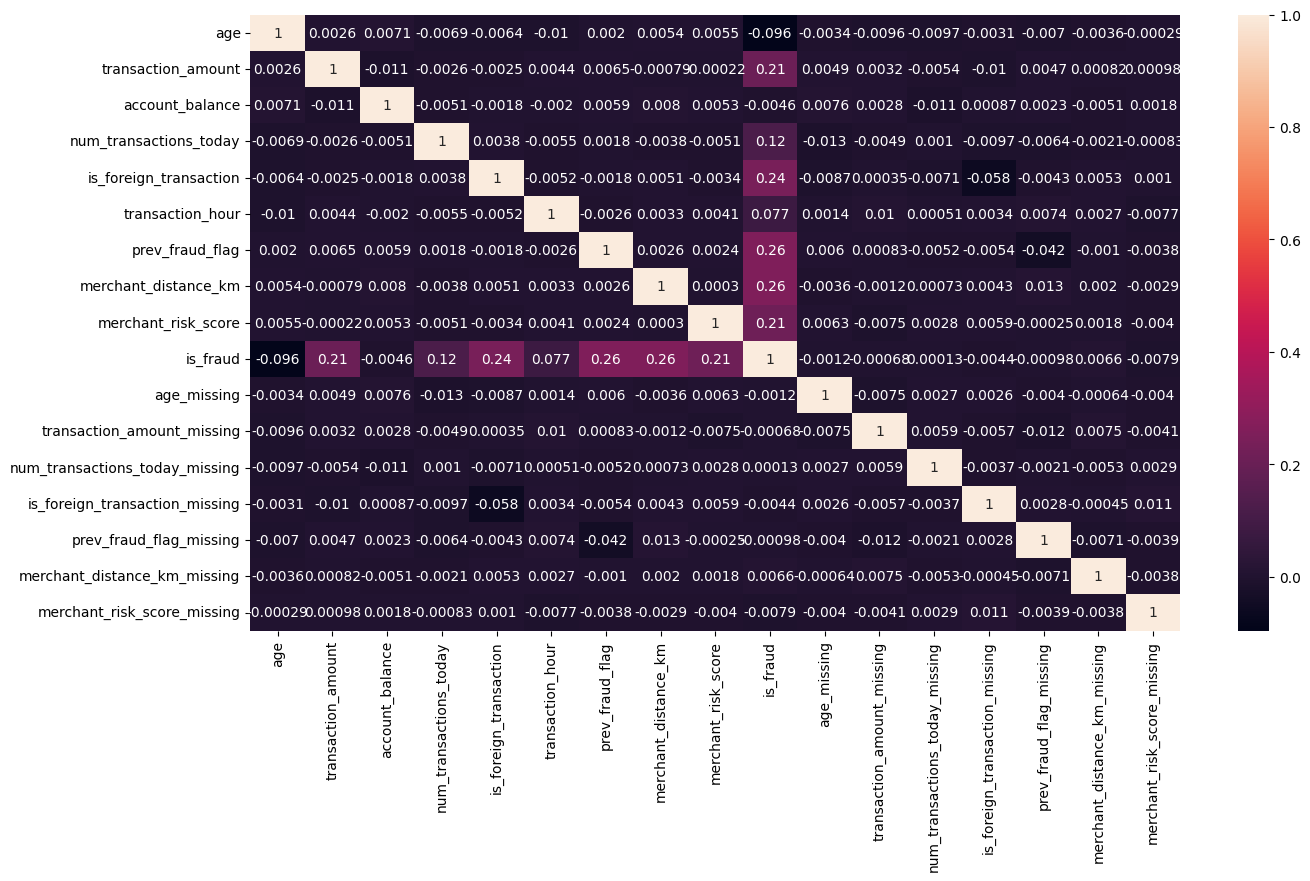

In [30]:
plt.figure(figsize = (15, 8))
sns.heatmap(df.corr(), annot = True)
plt.show()

In [ ]:
X = 
y = 